In [1]:
import geopandas
import shapely.geometry

In [13]:
mad_gcs = geopandas.read_file("City_Limit.zip")
water_gcs = geopandas.read_file("Lakes_and_Rivers.zip")
fire_gcs = geopandas.read_file("Fire_Stations.zip")
water_gcs.explore()

<Axes: >

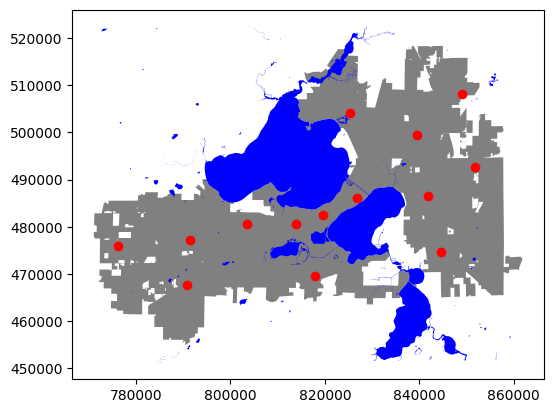

In [4]:
ax = mad_gcs.plot(color = "gray")
water_gcs.plot(color = "blue", ax = ax)
fire_gcs.plot(color = "red", ax = ax)

In [6]:
water_gcs.area

0      39958.447515
1      31880.854330
2       3699.958812
3       1174.258983
4      40693.432262
           ...     
184     4346.270473
185     3036.647240
186    59661.895832
187    20779.310395
188    49714.018294
Length: 189, dtype: float64

<Axes: >

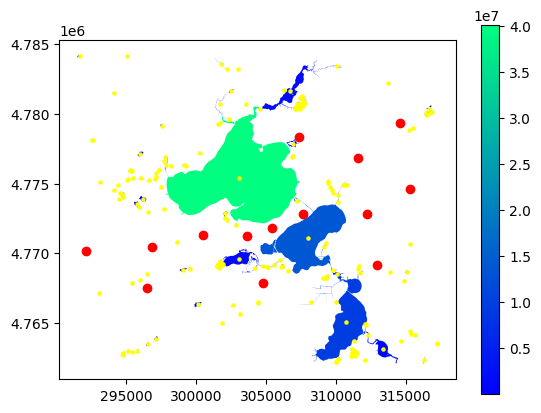

In [7]:
mad = mad_gcs.to_crs("epsg:32616")
water = water_gcs.to_crs(mad.crs)
fire = fire_gcs.to_crs(mad.crs)
ax = water.plot(water.area, cmap="winter", legend = True)
water.centroid.plot(color = "yellow", markersize = 5, ax = ax)
fire.plot(color = "red", ax = ax)


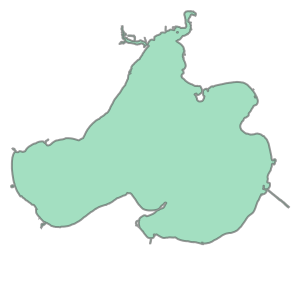

In [11]:
area = water.area
largest = water.iloc[area.idxmax()].geometry
largest

In [9]:
area

0      3712.802765
1      2962.225674
2       343.792285
3       109.109780
4      3781.226023
          ...     
184     403.845199
185     282.158435
186    5543.606944
187    1930.763217
188    4619.252051
Length: 189, dtype: float64

<Axes: >

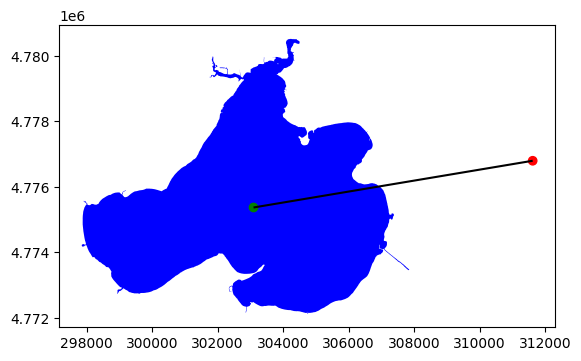

In [12]:
center = water.centroid[area.idxmax()]
closest = fire.iloc[0].geometry
station = 0
distance = center.distance(closest)
for index, row in fire.iterrows():
    if center.distance(row.geometry) < distance:
        closest = row.geometry
        station = index
ax = geopandas.GeoSeries([largest, center, closest]).plot(color = ["blue", "green", "red"])
geopandas.GeoSeries(shapely.geometry.LineString([center, closest])).plot(color = "black", ax = ax)